In [1]:
from swing_backtester_with_scaling import SwingBacktesterWithScaling

bt = SwingBacktesterWithScaling('gold_data_5_minutes_completed.csv', swing_window=6, sl_multiplier=2)
bt.run_backtest()
bt.summary_stats()
bt.plot_cumulative_pnl()




KeyboardInterrupt



In [15]:
bt.bt.describe()

,Entry Time,Exit Time,Entry Price,Exit Price,PnL,SL Price,Units
count,2512,2512,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,2024-06-09 04:14:22.141719808,2024-06-09 06:47:20.326433280,2398.615642,2398.658037,3.583567,2398.658037,1.692277
min,2023-06-14 05:40:00,2023-06-14 07:25:00,1818.050000,1817.990000,-39.200000,1817.990000,1.000000
25%,2023-12-13 14:25:00,2023-12-13 15:07:30,2018.912500,2018.807500,-0.392500,2018.807500,1.000000
50%,2024-06-12 18:12:30,2024-06-12 21:37:30,2350.115000,2350.015000,-0.090000,2350.015000,1.000000
75%,2024-12-05 17:02:30,2024-12-05 20:47:30,2662.617500,2661.695000,-0.010000,2661.695000,2.000000
max,2025-06-02 20:50:00,2025-06-02 20:55:00,3479.360000,3480.610000,445.640000,3480.610000,15.000000
std,NaN,NaN,412.736992,412.748950,21.464460,412.748950,1.503630


Index(['o', 'h', 'l', 'c', 'swings_high', 'swings_low'], dtype='object')
                           o        h        l        c  swings_high  \
timestamp                                                              
2023-06-14 00:00:00  1944.19  1944.58  1942.30  1943.41        False   
2023-06-14 00:05:00  1943.66  1944.48  1943.00  1944.48        False   
2023-06-14 00:10:00  1944.82  1944.88  1944.00  1944.49        False   
2023-06-14 00:15:00  1944.75  1945.36  1944.75  1945.36         True   
2023-06-14 00:20:00  1945.23  1945.23  1944.60  1945.08        False   

                     swings_low  
timestamp                        
2023-06-14 00:00:00       False  
2023-06-14 00:05:00       False  
2023-06-14 00:10:00       False  
2023-06-14 00:15:00       False  
2023-06-14 00:20:00       False  
✅ Total trades generated: 6764
           Entry Time           Exit Time Direction  Entry Price  Exit Price  \
0 2023-06-14 00:35:00 2023-06-14 00:40:00      Long  1945.080000     1944

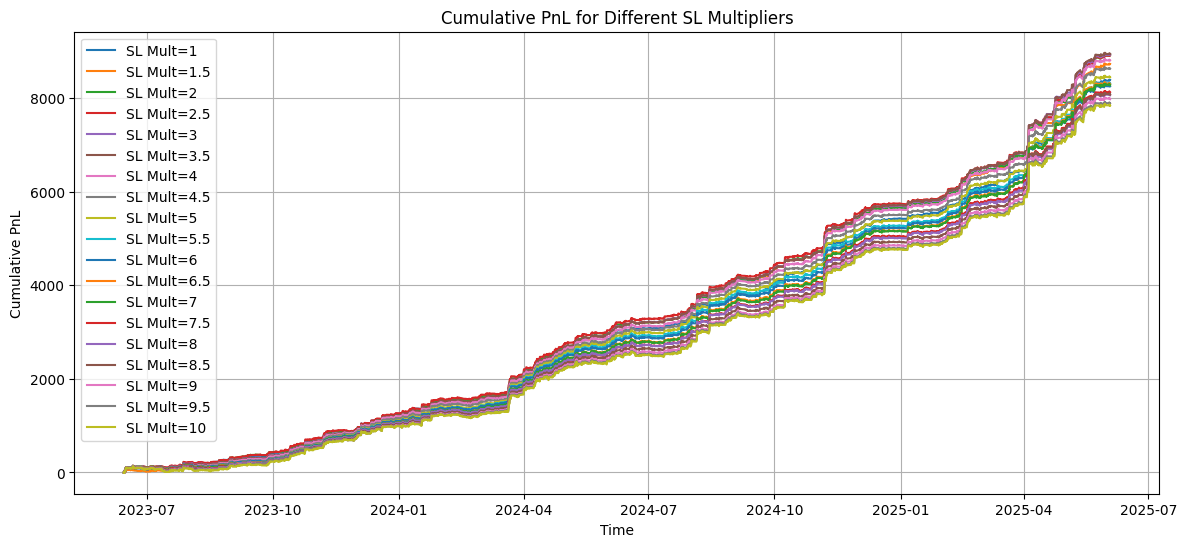

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from swing_backtester_with_scaling import SwingBacktesterWithScaling

excel_path = 'swing_detection_outputs.xlsx'
window = 1
sl_multipliers = [1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10]

bt = SwingBacktesterWithScaling(excel_path, swing_window=window, sl_multiplier=sl_multipliers[0])

summary_rows = []
results = {}

for sl_mult in sl_multipliers:
    bt.sl_multiplier = sl_mult
    bt.run_backtest()
    bt.calculate_mae_mfe()
    bt_df = bt.bt.copy()
    results[sl_mult] = bt_df

    if not bt_df.empty:
        total_trades = len(bt_df)
        win_trades = (bt_df['PnL'] > 0).sum()
        loss_trades = (bt_df['PnL'] < 0).sum()
        win_rate = win_trades / total_trades * 100 if total_trades else 0
        total_pnl = bt_df['PnL'].sum()
        avg_pnl = bt_df['PnL'].mean()
        max_drawdown = (bt_df['Cumulative PnL'].cummax() - bt_df['Cumulative PnL']).max()
        avg_win = bt_df.loc[bt_df['PnL'] > 0, 'PnL'].mean()
        avg_loss = bt_df.loc[bt_df['PnL'] < 0, 'PnL'].mean()
        rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
        avg_mae = bt_df['MAE'].mean()
        max_mae = bt_df['MAE'].min()
        avg_mfe = bt_df['MFE'].mean()
        max_mfe = bt_df['MFE'].max()
        winning_pnl = bt_df.loc[bt_df['PnL'] > 0, 'PnL'].sum()
        losing_pnl = bt_df.loc[bt_df['PnL'] < 0, 'PnL'].sum()
        efficiency = (bt_df['PnL'] / bt_df['MFE']) * 100
        avg_efficiency = efficiency.mean()
        summary_rows.append({
            'SL Multiplier': sl_mult,
            'Total Trades': total_trades,
            'Win Rate (%)': win_rate,
            'Total PnL': total_pnl,
            'Average PnL': avg_pnl,
            'Max Drawdown': max_drawdown,
            'Risk-Reward': rr,
            'Avg Win': avg_win,
            'Avg Loss': avg_loss,
            'Average MAE': avg_mae,
            'Max MAE': max_mae,
            'Average MFE': avg_mfe,
            'Max MFE': max_mfe,
            'Winning PnL': winning_pnl,
            'Losing PnL': losing_pnl,
            'Avg Trade Efficiency (%)': avg_efficiency
        })

# Create summary DataFrame
sl_summary_df = pd.DataFrame(summary_rows)
print(sl_summary_df.head(5))

# Plot cumulative PnL for all SL multipliers
plt.figure(figsize=(14, 6))
for sl_mult, bt_df in results.items():
    if not bt_df.empty:
        bt_df = bt_df.set_index('Exit Time')
        plt.plot(bt_df['Cumulative PnL'], label=f'SL Mult={sl_mult}')
plt.title('Cumulative PnL for Different SL Multipliers')
plt.xlabel('Time')
plt.ylabel('Cumulative PnL')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print(bt.data['entry_signal'].value_counts())


entry_signal
 0.0    129462
-1.0      4763
 1.0      3855
Name: count, dtype: int64


In [4]:
print(sl_summary_df)

   SL Multiplier  Total Trades  Win Rate (%)  Total PnL  Average PnL  \
0            1.0          6764     24.068598    8384.16     1.239527   
1            1.5          6648     25.541516    8726.19     1.312604   
2            2.0          6573     26.776206    8912.49     1.355924   

   Max Drawdown  Risk-Reward   Avg Win  Avg Loss  Average MAE  Max MAE  \
0        51.080     8.284489  7.834122 -0.945637     0.158313  -54.955   
1        59.055     7.136919  8.112839 -1.136742     0.169847  -54.955   
2        64.160     6.388458  8.211659 -1.285390     0.177301  -54.955   

   Average MFE    Max MFE  Winning PnL  Losing PnL  Avg Trade Efficiency (%)  
0    -0.300893  31.055714     12753.95    -4369.79                 -8.231139  
1    -0.310310  34.793636     13775.60    -5049.41                 -7.345496  
2    -0.321946  37.340000     14452.52    -5540.03                 -7.451103  


In [11]:
sl_summary_df.to_excel('abc.xlsx')